In [13]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../bonds_dashboards/backend/llm/fomc_training_data.csv")

df.head()

,date,decision,fed_funds_rate,full_text,text_length,economic_outlook,policy_discussion,risks_concerns,future_guidance
0,"January 30-31, 2018",hold,1.50,Minutes of the Federal Open Market Committee J...,83099,of the Economic Situation The information revi...,and to take actions that may result in materia...,", including risks to the financial system that...",NaN
1,"March 20-21, 2018",hike,1.75,Minutes of the Federal Open Market Committee M...,93397,of the Economic Situation The information revi...,communications over the intermeeting period in...,about the prospects for higher inflation and h...,"and large-scale asset purchases, to provide ad..."
2,"May 1-2, 2018",hold,1.75,Minutes of the Federal Open Market Committee M...,53230,of the Economic Situation The information revi...,by setting the IOER rate modestly below the to...,about the outlook for trade policy both in the...,NaN
3,"June 12-13, 2018",hike,2.00,Minutes of the Federal Open Market Committee J...,90501,of the Economic Situation The information revi...,and in the absence of further shocks to the ec...,about the political situation in Italy and its...,"and large-scale asset purchases, to provide ad..."
4,"July 31-August 1, 2018",hold,2.00,Minutes of the Federal Open Market Committee J...,56294,were to warrant a more accommodative monetary ...,options at the effective lower bound. A. Lee S...,about trade tensions had not affected the outl...,and balance sheet actions could provide additi...


In [3]:
df['full_text'] = df['full_text'].astype(str)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

C:\Users\denis\AppData\Local\Temp\ipykernel_16980\1557040872.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [4]:
df['char_len'] = df['full_text'].str.len()
df['word_len'] = df['full_text'].str.split().str.len()

In [5]:
hawkish_words = [
    "inflation", "overheating", "tightening", "rates higher",
    "hawkish", "elevated", "pressure"
]

dovish_words = [
    "accommodative", "slowdown", "softening", "dovish",
    "cut", "lower rates", "support"
]

In [6]:
def count_words(text, words):
    text_low = text.lower()
    count = 0
    for w in words:
        count += text_low.count(w)
    return count

In [7]:
df['hawk_count'] = df['full_text'].apply(lambda x: count_words(x, hawkish_words))
df['dove_count'] = df['full_text'].apply(lambda x: count_words(x, dovish_words))

df['hawkish_score'] = (df['hawk_count'] - df['dove_count']) / df['word_len']

In [8]:
df['inflation_mentions'] = df['full_text'].str.lower().str.count("inflation")

In [10]:
df = df.sort_values("date")

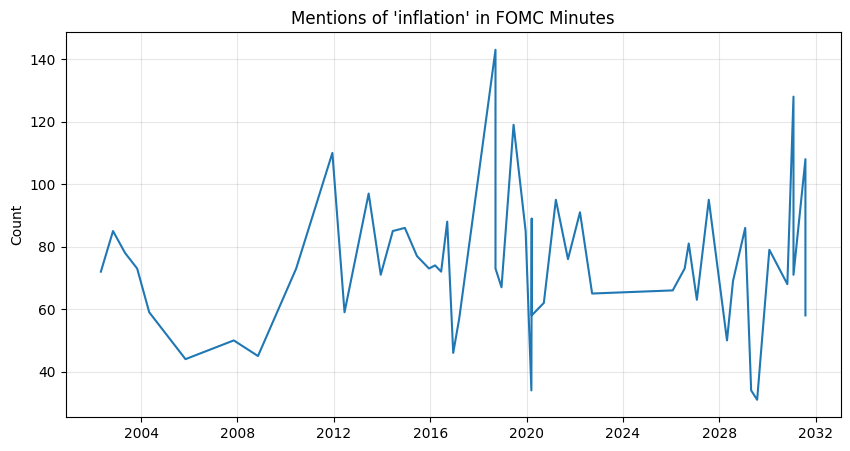

In [11]:
plt.figure(figsize=(10,5))
plt.plot(df['date'], df['inflation_mentions'])
plt.title("Mentions of 'inflation' in FOMC Minutes")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

In [12]:
out = df[['date', 'char_len', 'word_len',
          'hawk_count', 'dove_count', 'hawkish_score',
          'inflation_mentions']]

out.to_csv("../data/fomc_text_features.csv", index=False)

out.head()

,date,char_len,word_len,hawk_count,dove_count,hawkish_score,inflation_mentions
2,2002-05-01 20:18:00,53230,8296,95,21,0.008920,72
38,2002-11-01 20:22:00,56343,8524,134,12,0.014313,85
42,2003-05-02 20:23:00,57190,8807,127,14,0.012831,78
30,2003-11-02 20:21:00,57649,8649,100,41,0.006822,73
34,2004-05-03 20:22:00,54548,8321,113,14,0.011898,59


Missing 10Y yields after merge: 21


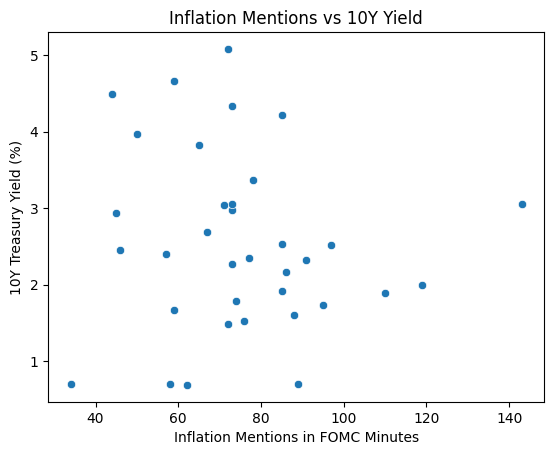

In [21]:
macro = pd.read_csv("../macro_monthly_clean.csv", index_col=0, parse_dates=True)

macro["date"] = macro.index

df["date"] = pd.to_datetime(df["date"]).dt.to_period("M").dt.to_timestamp("M")

merged = df.merge(macro, on="date", how="left")

print("Missing 10Y yields after merge:", merged["treasury_10y"].isna().sum())

sns.scatterplot(data=merged, x="inflation_mentions", y="treasury_10y")
plt.title("Inflation Mentions vs 10Y Yield")
plt.xlabel("Inflation Mentions in FOMC Minutes")
plt.ylabel("10Y Treasury Yield (%)")
plt.show()